In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# 1. Reloading Data

In [2]:
X_train = np.load("processed_data/X_train.npy")
X_test = np.load("processed_data/X_test.npy")
y_train = np.load("processed_data/y_train.npy")
y_test = np.load("processed_data/y_test.npy")

X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1) 


# 2. Loading Model
- Saved entire bayes search object so we can do further analysis of the hyperparameter tuning

In [3]:
bayes_search = joblib.load("bayes_search_knn_full.pkl") # loading the best model (saved after hyperparameter tuning)

best_knn = bayes_search.best_estimator_ # defining the model parameters for our tuned model

# 3. Forming Predictions on Test Data

In [4]:
# fitting the label encoder on training labels
le = LabelEncoder()
le.fit(y_train)

# generating encoded predictions on test set
y_pred_enc = best_knn.predict(X_test)

# converting predictions back to labels (genres)
y_pred_labels = le.inverse_transform(y_pred_enc)

# 4. Analyze Hyperparameter Tuning Results
- Visualize how different values of k (number of neighbors) affect the F1 score
- This helps us understand the relationship between k and model performance

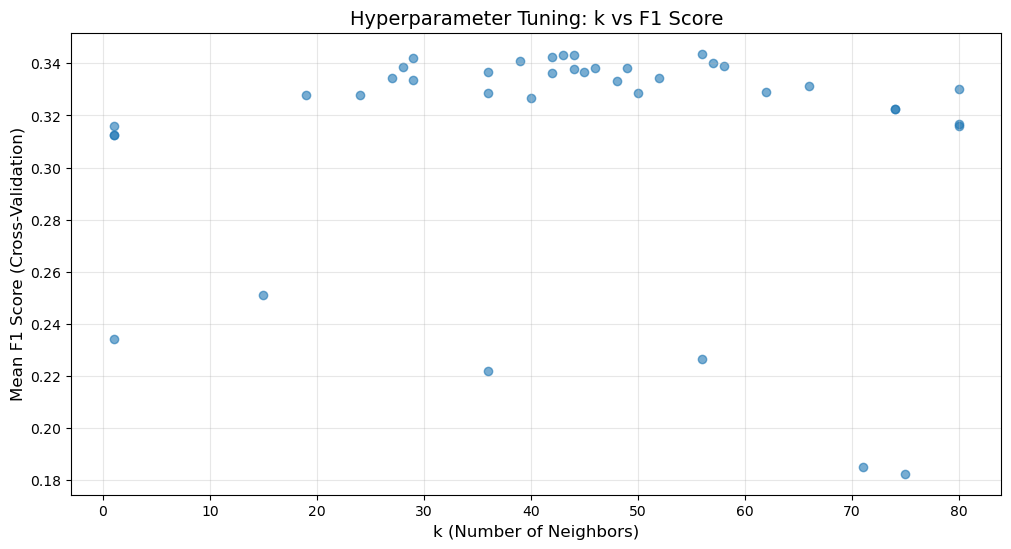

Best F1 Score: 0.3437
Best Parameters: OrderedDict([('metric', 'manhattan'), ('n_neighbors', 56), ('weights', 'distance')])


In [5]:
# Extract results from non-PCA hyperparameter search
cv_results_df = pd.DataFrame(bayes_search.cv_results_)

# Plot k vs F1 Score for non-PCA
plt.figure(figsize=(12, 6))
plt.scatter(cv_results_df['param_n_neighbors'], cv_results_df['mean_test_score'], alpha=0.6)
plt.xlabel('k (Number of Neighbors)', fontsize=12)
plt.ylabel('Mean F1 Score (Cross-Validation)', fontsize=12)
plt.title('Hyperparameter Tuning: k vs F1 Score', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Best F1 Score: {bayes_search.best_score_:.4f}")
print(f"Best Parameters: {bayes_search.best_params_}")

# 5. Model Evaluation and Comparison
- Use the best models from hyperparameter tuning to make predictions on test data
- Compare performance metrics (accuracy, precision, recall, F1-score)
- Generate classification reports to see performance for each genre

In [6]:
# Calculate metrics for model
print("="*70)
print("MODEL PERFORMANCE - FULL SONGS")
print("="*70)
print(f"\nBest Hyperparameters: {bayes_search.best_params_}")
print(f"Best Cross-Validation F1 Score: {bayes_search.best_score_:.4f}")
print(f"\nTest Set Accuracy: {accuracy_score(y_test, y_pred_labels):.4f}")
print(f"Test Set F1 Score (Macro): {f1_score(y_test, y_pred_labels, average='macro'):.4f}")
print(f"Test Set Precision (Macro): {precision_score(y_test, y_pred_labels, average='macro'):.4f}")
print(f"Test Set Recall (Macro): {recall_score(y_test, y_pred_labels, average='macro'):.4f}")

print("\n" + "="*70)
print("Classification Report:")
print("="*70)
print(classification_report(y_test, y_pred_labels))

MODEL PERFORMANCE - FULL SONGS

Best Hyperparameters: OrderedDict([('metric', 'manhattan'), ('n_neighbors', 56), ('weights', 'distance')])
Best Cross-Validation F1 Score: 0.3437

Test Set Accuracy: 0.3163
Test Set F1 Score (Macro): 0.2748
Test Set Precision (Macro): 0.2904
Test Set Recall (Macro): 0.3231

Classification Report:
              precision    recall  f1-score   support

       blues       0.27      0.15      0.19        20
   classical       0.89      0.42      0.57        19
     country       0.00      0.00      0.00        20
       disco       0.26      0.30      0.28        20
      hiphop       0.29      0.65      0.40        20
        jazz       0.23      0.35      0.27        20
       metal       0.30      0.83      0.44        18
         pop       0.67      0.53      0.59        19
      reggae       0.00      0.00      0.00        20
        rock       0.00      0.00      0.00        20

    accuracy                           0.32       196
   macro avg       0

/opt/miniconda3/envs/ecs171-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/ecs171-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/ecs171-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

# 6. Performance Analysis by Genre
- Identify which genres are classified correctly vs incorrectly
- Understand which genres are commonly confused with each other
- Analyze performance metrics for each individual genre

PER-GENRE PERFORMANCE METRICS
           precision    recall  f1-score  support
blues       0.272727  0.150000  0.193548     20.0
classical   0.888889  0.421053  0.571429     19.0
country     0.000000  0.000000  0.000000     20.0
disco       0.260870  0.300000  0.279070     20.0
hiphop      0.288889  0.650000  0.400000     20.0
jazz        0.225806  0.350000  0.274510     20.0
metal       0.300000  0.833333  0.441176     18.0
pop         0.666667  0.526316  0.588235     19.0
reggae      0.000000  0.000000  0.000000     20.0
rock        0.000000  0.000000  0.000000     20.0


/opt/miniconda3/envs/ecs171-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/ecs171-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/ecs171-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

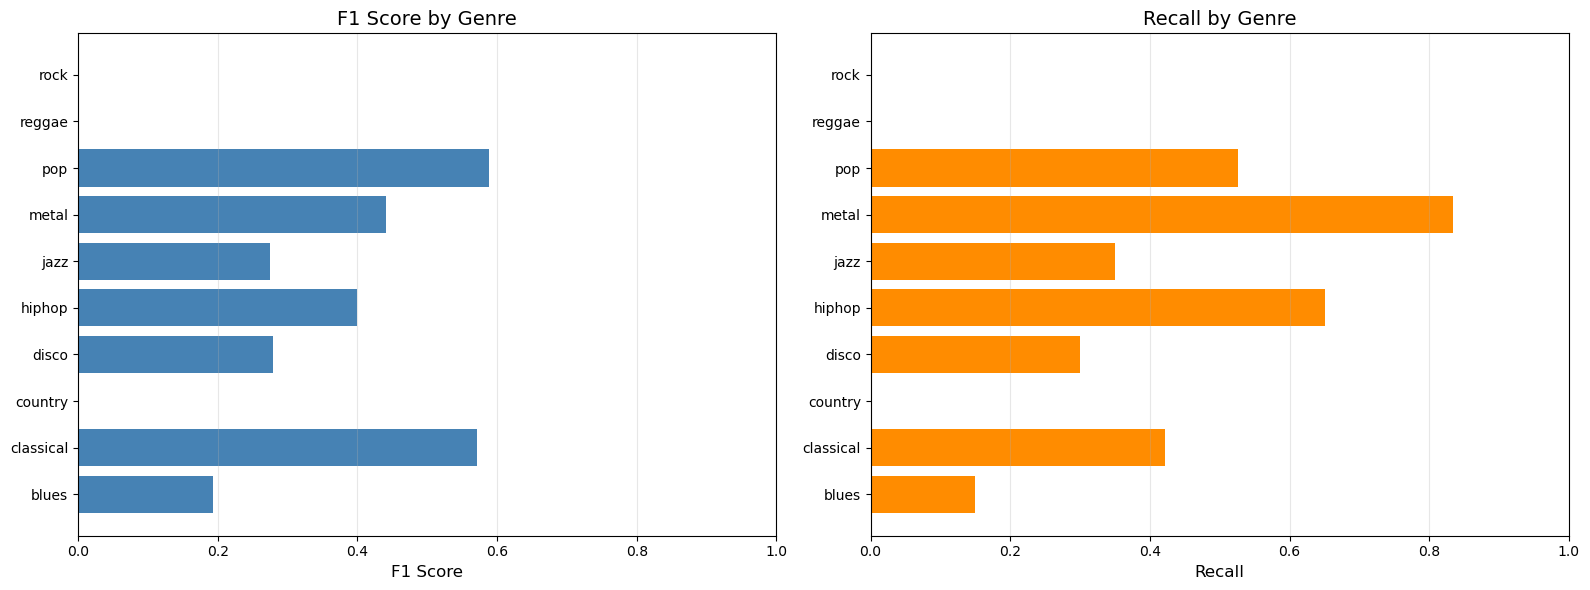

In [7]:
# making a list of all the genres
genres = sorted(np.unique(y_test))

# Get detailed performance metrics by genre
report = classification_report(y_test, y_pred_labels, output_dict=True)

# Convert to DataFrame for better visualization
df_report = pd.DataFrame(report).transpose()

# Display genre-level metrics
print("="*70)
print("PER-GENRE PERFORMANCE METRICS")
print("="*70)
print(df_report.head(len(genres)))

# Extract F1 and recall (per-genre accuracy)
f1_scores = [report[genre]['f1-score'] for genre in genres]
accuracy_by_genre = [report[genre]['recall'] for genre in genres]

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot F1 scores
ax1.barh(genres, f1_scores, color='steelblue')
ax1.set_xlabel('F1 Score', fontsize=12)
ax1.set_title('F1 Score by Genre', fontsize=14)
ax1.set_xlim(0, 1)
ax1.grid(axis='x', alpha=0.3)

# Plot accuracy (recall) by genre
ax2.barh(genres, accuracy_by_genre, color='darkorange')
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_title('Recall by Genre', fontsize=14)
ax2.set_xlim(0, 1)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# defining function to compute the number of songs predicted across all genres for the positive genre

def plot_prediction_frequency(target_genre):

    rates = [] # will hold the rate of not target_genre for all songs that are the target_genre

    for g in genres: # looping through each genre
        subset = y_pred_labels[y_test == g] # separating to get only songs of the true_genre
        rate = np.mean(subset == target_genre) # calculates the proportion predicted as target_genre
        rates.append(rate) # appends to list

    sns.barplot(x=genres, y=rates) # creates barplot to display rates by genre

    plt.xticks(rotation=45)
    plt.ylabel(f"Proportion Predicted as {target_genre.capitalize()}")
    plt.xlabel("True Genre")
    plt.title(f"Frequency of {target_genre.capitalize()} Predictions by True Genre")

    plt.show()

In [18]:
def prediction_plot_true_genre(genre):
    
    # get indices of songs with the specified true genre
    genre_idx = (y_test == genre)
    
    # predictions for those songs
    genre_preds = y_pred_labels[genre_idx]
    
    # count predictions
    genre_counts = pd.Series(genre_preds).value_counts()
    
    # convert to proportions
    genre_props = genre_counts / genre_counts.sum()
    
    # plot
    genre_props.sort_values(ascending=False).plot(kind="bar")
    
    plt.title(f"Predicted Genres for True {genre.capitalize()} Songs")
    plt.xlabel("Predicted Genre")
    plt.ylabel("Proportion")
    plt.show()

## Metal
- Highest recall, relatively high F1 score, average precision
- Actual metal songs are consistently classified as metal
    - False negatives are low (can see this in the second plot)
- But, classifying other songs as metal - leading to low precision 
    - High false positives
    - Suggests metal is acting as a catch all for other genres
    - Observing many false positives
- First plot shows that 4 genres with > 30% of those songs being predicted as metal

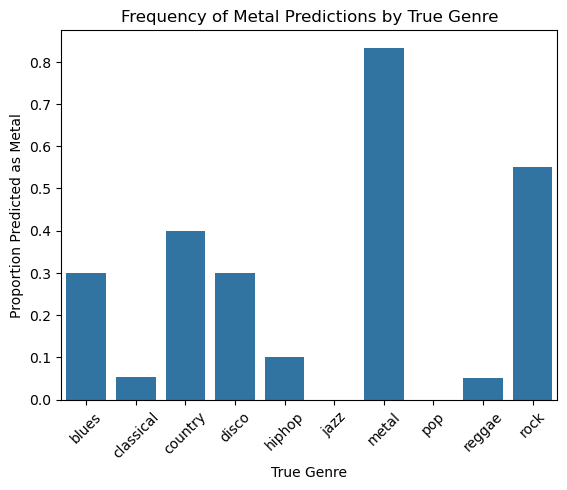

In [9]:
plot_prediction_frequency("metal")

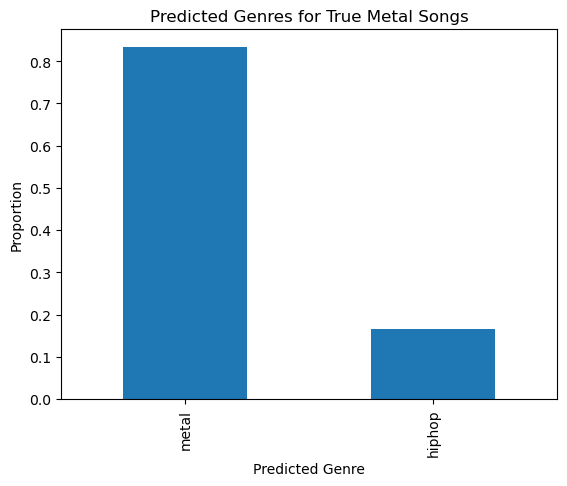

In [20]:
prediction_plot_true_genre("metal")

## Jazz
- Average F1 score, slightly lower than average precision, average recall
- Suggests high number of false positives
- Supported with the figure + code below
    - See in the figure that across all genres, the proportion of times songs in those genres are predicted as jazz is large
    - The percentage of songs that aren't jazz being mis-classified as jazz ~ 14%
- Suggests the jazz cluster overlaps with other nearby clusters like country, blues, reggae, rock

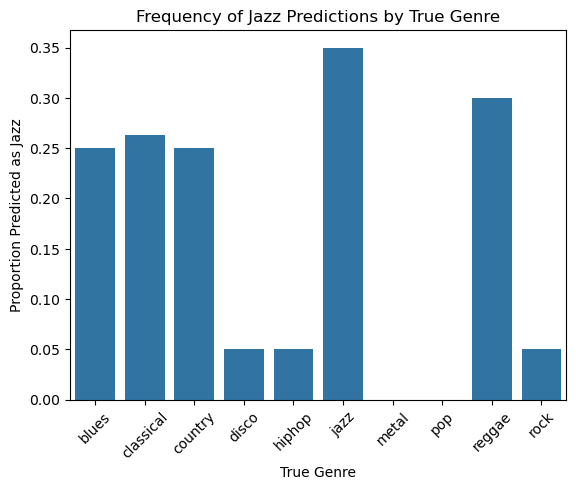

In [10]:
plot_prediction_frequency("jazz")

In [11]:
np.mean(y_pred_labels[y_test != "jazz"] == "jazz")

np.float64(0.13636363636363635)

## Classical
- Performs very well in comparison to other genres
- Very high precision, higher than average F1 score and recall

## Country
- 0 precision, recall, and f1 score
- Second song shows how country songs are being classified
    - Many are classified as metal (40%), supports earlier suggestion that metal is acting almost as a default cluster
- The model is predicting country, but it never predicts country correctly

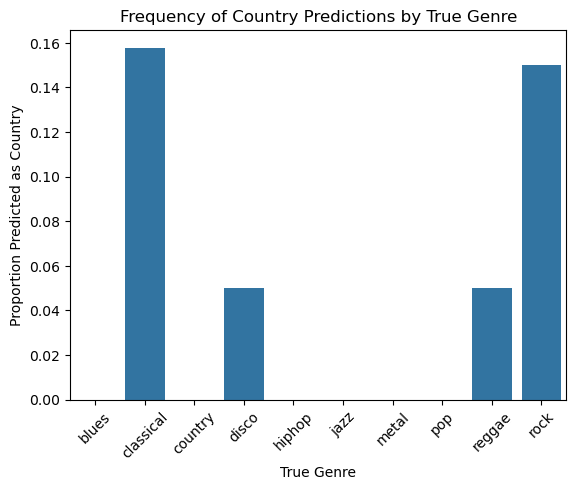

In [13]:
plot_prediction_frequency("country")

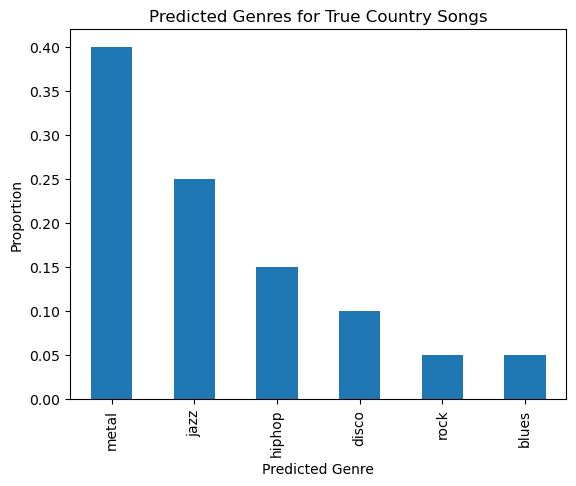

In [19]:
prediction_plot_true_genre("country")

In [15]:
sum(y_pred_labels == "country")

np.int64(8)

## Blues
- Average precision, low recall and F1
- Looking at the figure below, see the stronger clusters are taking over
    - Only correctly classifying blues songs 15% of the time
- The model is conservative in predicting blues
- Suggests that blues cluster could sit near jazz cluster, which explains the large number of jazz predictions
- Also supports earlier conclusion about metal, that this label dominates 

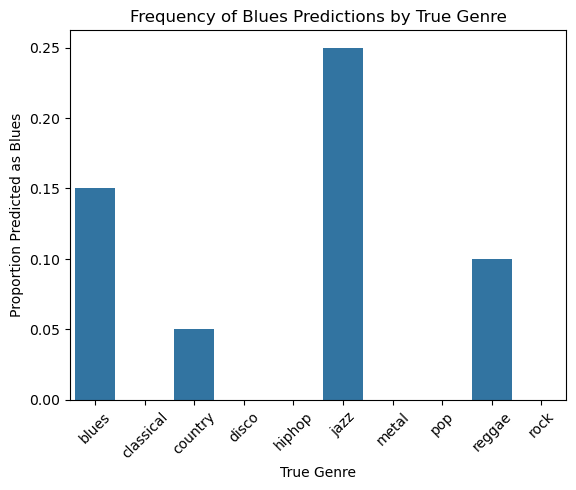

In [12]:
plot_prediction_frequency("blues")

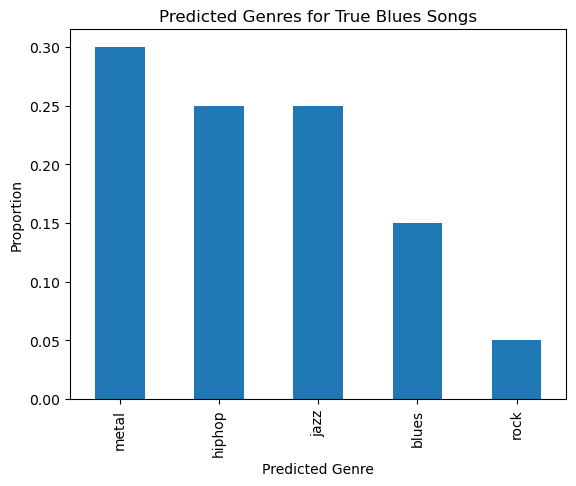

In [22]:
prediction_plot_true_genre("blues")

## Pop & Reggae
- Have similar trend
- High precision but low recall and F1 score
- This means that the model doesn't often predict pop or reggae, but when it does this prediction is accurate
- Suggests these clusters are well-defined in the feature space, but other clusters dominate 
    - Could also be that the clusters are narrow/close to other clusters that are predicted more

## Disco & Hip Hop
- Seem to interact
- Disco has low precision, recall, and F1 score (worst performing genre)
- Out of disco songs, most of the predictions are hip hop and metal
- Hip hop has high recall but low precision and F1 score
    - Seems to have a similar trend to jazz, but less extreme

## Rock
- Low F1, recall, and precision
- 45% of rock songs are classified as metal
- Hip hop and jazz also significant presence
- Suggests these other clusters dominate, leading to poor performance in this genre

# 4. Results Interpretation and Discussion

### Comparing the Models:
Compare the test set performance metrics between non-PCA and PCA models:
- **Accuracy**: Which model has higher overall accuracy?
- **F1 Score**: Which model better balances precision and recall?
- **Per-Genre Performance**: Are there specific genres that benefit more from PCA?

## Genre Classification Patterns
**Easier to Classify Genres** typically have:
- Distinctive audio features (e.g., metal has high energy and tempo; classical has distinct instrument timbres)
- Consistent patterns within the genre
- Clear separation from other genres in feature space

**Harder to Classify Genres** often have:
- Overlapping characteristics with other genres (e.g., rock and metal; pop and dance)
- High within-genre variability
- Fusion elements from multiple genres


# Analysis of Results

Based on the plots and metrics generated above, here are the key findings:

## Genre-Specific Insights

### Best Performing Genres:
From the F1 score bar charts in section 9, identify genres with F1 > 0.7:
- These genres likely have distinctive audio characteristics
- Clear separation in feature space from other genres
- Consistent patterns within the genre

### Worst Performing Genres:
Identify genres with F1 < 0.4:
- High overlap with similar genres
- Within-genre variability makes them hard to classify
- May benefit from additional features or different preprocessing